Importing Libraries

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn import metrics

Data collection and Processing

In [62]:
#loading the csv data to a pandas dataframe
gold_data = pd.read_csv('/content/gld_price_data.csv')

will not be donting forcasting so will remove date will not be using date columns


and if we  wanna do forcasting we can use
LSTM model: long short term memory model

In [63]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [64]:
gold_data.shape

(2290, 6)

In [65]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [66]:
gold_data.drop(columns = 'Date',axis=1,inplace=True)

In [67]:
gold_data.head()

,SPX,GLD,USO,SLV,EUR/USD
0,1447.160034,84.860001,78.470001,15.180,1.471692
1,1447.160034,85.570000,78.370003,15.285,1.474491
2,1411.630005,85.129997,77.309998,15.167,1.475492
3,1416.180054,84.769997,75.500000,15.053,1.468299
4,1390.189941,86.779999,76.059998,15.590,1.557099


In [68]:
# getting basic info about data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SPX      2290 non-null   float64
 1   GLD      2290 non-null   float64
 2   USO      2290 non-null   float64
 3   SLV      2290 non-null   float64
 4   EUR/USD  2290 non-null   float64
dtypes: float64(5)
memory usage: 89.6 KB


In [69]:
#cheak the missing values
gold_data.isnull().sum()

,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [70]:
 # getting the statestical measures
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:

positive correlation

Nagative correlation

In [71]:
correlation = gold_data.corr()

<Axes: >

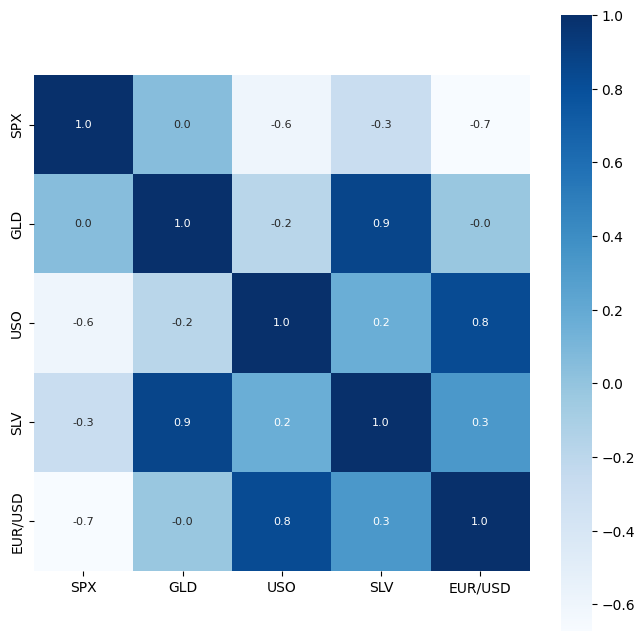

In [72]:
#constructing a Heatmap
plt.figure(figsize=(8,8))
sns.heatmap(correlation,cbar=True ,square=True,fmt='.1f', annot=True,annot_kws={'size':8},cmap='Blues')
#


In [73]:
#correlation Values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_4131/3574491250.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color='y')


<Axes: xlabel='GLD', ylabel='Density'>

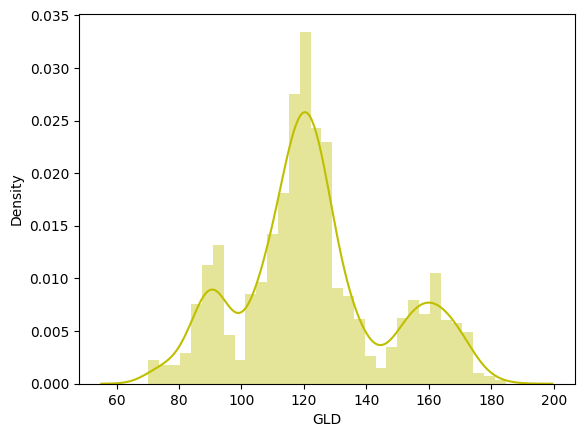

In [74]:
# cheaking the distrubution of the GLD price
sns.distplot(gold_data['GLD'], color='y')

Splitting the Features and the Targets

In [75]:
X = gold_data.drop(['GLD'],axis=1)
Y = gold_data['GLD']

In [76]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [77]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [78]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

Model Training:

Random Forest Regressor

In [79]:
regressor = RandomForestRegressor(n_estimators=100)

In [80]:
#tranning the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation

In [81]:
# predicting on the test data
test_data_predictiton = regressor.predict(X_test)

In [82]:
print(test_data_predictiton)

[168.48159917  82.0749999  115.83550008 127.63570062 120.81730099
 154.71419788 150.26039868 126.25030001 117.66399864 125.98220068
 116.74730076 171.59860092 141.49489872 167.82949841 115.24780003
 117.63810026 139.78930283 170.06360083 159.66770245 160.80449883
 155.23900033 125.03620026 175.97210036 157.05110263 125.20820046
  93.78179953  77.67360009 120.74470001 119.12339956 167.44770003
  88.22710053 125.29319977  91.00740088 117.56580054 121.10509912
 136.33640085 115.40230122 115.11740074 148.30199966 106.91460076
 104.62030239  87.1027977  126.53850026 117.79999994 153.91379883
 119.69379983 108.23470059 108.48999863  93.17780053 127.03479814
  74.9405005  113.65999932 121.25990033 111.24459881 118.88649888
 120.26029962 159.09709955 168.62890106 147.21359692  85.99669856
  94.45990047  86.99869849  90.64790021 118.88120075 126.42690053
 127.61540008 169.28760021 122.3042994  117.30049912  98.61510052
 168.18520264 143.35789905 132.44360241 121.28840202 121.58789941
 119.74690

In [83]:
# R squared error
error_score = metrics.r2_score(Y_test,test_data_predictiton)
print("R squared error : ",error_score)


R squared error :  0.9887648897399897


Compare The Actual Values And Predicted Values in plot

In [84]:
Y_test = list(Y_test)

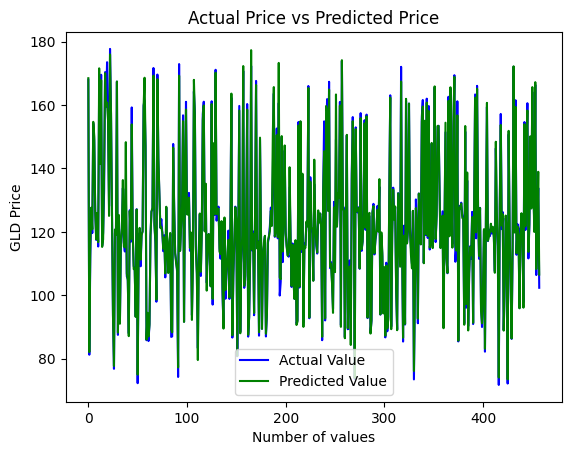

In [88]:
plt.plot(Y_test,color='blue',label='Actual Value')
plt.plot(test_data_predictiton,color='green',label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()

In [94]:
def predict_gold_price(SPX, USO, SLV, EUR_USD):
    # Create a DataFrame from the input values
    input_data = pd.DataFrame([[SPX, USO, SLV, EUR_USD]], columns=['SPX', 'USO', 'SLV', 'EUR/USD'])

    # Make a prediction using the trained regressor model
    predicted_price = regressor.predict(input_data)

    print(f"The predicted GLD price is: {predicted_price[0]:.2f}")

# Get input from the user
SPX_input = float(input("Enter SPX value: "))
USO_input = float(input("Enter USO value: "))
SLV_input = float(input("Enter SLV value: "))
EUR_USD_input = float(input("Enter EUR/USD value: "))

# Call the predictive system with user input
predict_gold_price(SPX=SPX_input, USO=USO_input, SLV=SLV_input, EUR_USD=EUR_USD_input)

Enter SPX value:  7408.50
Enter USO value: 148.34
Enter SLV value: 46.89
Enter EUR/USD value: 1.15
The predicted GLD price is: 166.42
